# DenseNet121 — Rahman

## 1. Load and check the shared dataset

In [1]:
from google.colab import drive
drive.mount('/content/drive')

!cp "/content/drive/MyDrive/Deep Learning Project/processed/gtsrb_data.npz" /content/
import numpy as np
data = np.load("/content/gtsrb_data.npz")
for name in data.files:
    arr = data[name]
    print(name, arr.shape, arr.dtype, "min:", arr.min(), "max:", arr.max())

Mounted at /content/drive
X_train (33327, 64, 64, 3) float32 min: 0.0 max: 1.0
y_train (33327,) int64 min: 0 max: 42
X_val (5882, 64, 64, 3) float32 min: 0.0 max: 1.0
y_val (5882,) int64 min: 0 max: 42
X_test (12630, 64, 64, 3) float32 min: 0.0 max: 1.0
y_test (12630,) int64 min: 0 max: 42


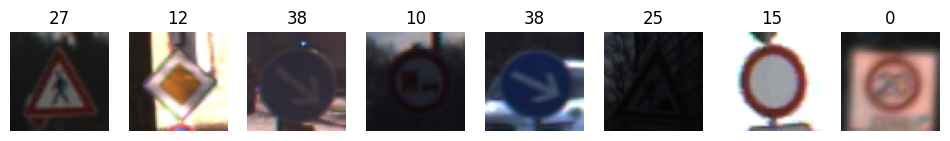

In [2]:
import matplotlib.pyplot as plt
X_train, y_train = data["X_train"], data["y_train"]

plt.figure(figsize=(12, 3))
for i in range(8):
    plt.subplot(1, 8, i + 1)
    plt.imshow(X_train[i])
    plt.title(y_train[i])
    plt.axis("off")
plt.show()

## 2. Prepare the data for PyTorch

In [3]:
import torch
X_train_t = torch.from_numpy(X_train)
print(type(X_train_t))
print(X_train_t.shape)

<class 'torch.Tensor'>
torch.Size([33327, 64, 64, 3])


In [4]:
X_train_t = torch.from_numpy(X_train).permute(0, 3, 1, 2)
print(X_train_t.shape)

torch.Size([33327, 3, 64, 64])


In [5]:
X_val, y_val = data["X_val"], data["y_val"]

X_val_t   = torch.from_numpy(X_val).permute(0, 3, 1, 2)
y_train_t = torch.from_numpy(y_train)
y_val_t   = torch.from_numpy(y_val)

print(X_val_t.shape, y_train_t.shape, y_val_t.shape)

torch.Size([5882, 3, 64, 64]) torch.Size([33327]) torch.Size([5882])


In [6]:
from torch.utils.data import TensorDataset, DataLoader

torch.manual_seed(42)

train_data = TensorDataset(X_train_t, y_train_t)
train_loader = DataLoader(train_data, batch_size=32, shuffle=True)

print(len(train_loader))

1042


In [7]:
val_data = TensorDataset(X_val_t, y_val_t)
val_loader = DataLoader(val_data, batch_size=32, shuffle=False)
print(len(val_loader))

images, labels = next(iter(train_loader))
print(images.shape)
print(labels)

184
torch.Size([32, 3, 64, 64])
tensor([15, 13, 16, 17, 22, 38,  0,  3,  5,  7,  7,  2,  9, 13, 34,  1, 18, 10,
        31, 12, 25,  7,  2, 24, 37, 12,  2, 24, 18,  9,  9, 38])


In [8]:
from torchvision import transforms

normalize = transforms.Normalize(mean=[0.485, 0.456, 0.406],
                                 std=[0.229, 0.224, 0.225])

print("before:", images.min().item(), images.max().item())
images_norm = normalize(images)
print("after:", images_norm.min().item(), images_norm.max().item())

before: 0.0 1.0
after: -2.1179039478302 2.640000104904175


## 3. Build the DenseNet121 model

In [9]:
from torchvision import models

model = models.densenet121(weights="IMAGENET1K_V1")
print(model.classifier)

Downloading: "https://download.pytorch.org/models/densenet121-a639ec97.pth" to /root/.cache/torch/hub/checkpoints/densenet121-a639ec97.pth


100%|██████████| 30.8M/30.8M [00:00<00:00, 138MB/s]

Linear(in_features=1024, out_features=1000, bias=True)


In [10]:
import torch.nn as nn

torch.manual_seed(42)  # group rule: seed 42, so the new layer starts the same way every run
model.classifier = nn.Linear(1024, 43)
print(model.classifier)

Linear(in_features=1024, out_features=43, bias=True)


In [11]:
for param in model.features.parameters():
    param.requires_grad = False

total = sum(p.numel() for p in model.parameters())
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print("total knobs:", total)
print("trainable knobs:", trainable)

total knobs: 6997931
trainable knobs: 44075


In [12]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("using:", device)
model = model.to(device)

using: cuda


In [13]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.classifier.parameters(), lr=0.001)

images, labels = next(iter(train_loader))
images = normalize(images).to(device)
labels = labels.to(device)

scores = model(images)
loss = criterion(scores, labels)
print(scores.shape)
print("loss:", loss.item())

torch.Size([32, 43])
loss: 3.9757704734802246


## 4. Augmentation (practice photos only)

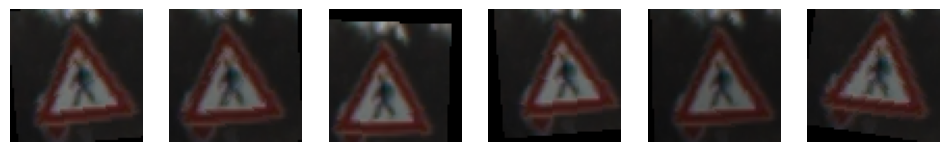

In [14]:
augment = transforms.Compose([
    transforms.RandomAffine(degrees=10, translate=(0.1, 0.1), scale=(0.9, 1.1)),
    transforms.ColorJitter(brightness=0.2),
])

photo = X_train_t[0]
plt.figure(figsize=(12, 3))
for i in range(6):
    plt.subplot(1, 6, i + 1)
    plt.imshow(augment(photo).permute(1, 2, 0))
    plt.axis("off")
plt.show()

## 6. Mock exam (validation)

In [15]:
def evaluate(loader):
    model.eval()
    total_loss, correct, count = 0, 0, 0
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            images = normalize(images)
            scores = model(images)
            total_loss += criterion(scores, labels).item()
            guesses = scores.argmax(dim=1)
            correct += (guesses == labels).sum().item()
            count += len(labels)
    return total_loss / len(loader), correct / count

val_loss, val_acc = evaluate(val_loader)
print("mock exam loss:", val_loss)
print("mock exam accuracy:", val_acc)

mock exam loss: 4.737812003363734
mock exam accuracy: 0.016150969058143488


In [21]:
import time

def train_one_epoch():
    model.train()
    total_loss = 0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        images = torch.stack([augment(img) for img in images])
        images = normalize(images)
        loss = criterion(model(images), labels)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(train_loader)

In [32]:


best_file = "/content/drive/MyDrive/densenet121_best.pt"
history = []
best_val_loss = float("inf")
epochs_without_improvement = 0

for epoch in range(1, 31):
    start = time.time()
    train_loss = train_one_epoch()
    val_loss, val_acc = evaluate(val_loader)
    seconds = round(time.time() - start)
    history.append({"phase": 1, "epoch": epoch, "train_loss": train_loss,
                    "val_loss": val_loss, "val_acc": val_acc, "seconds": seconds})
    print(f"epoch {epoch}: train loss {train_loss:.3f} | val loss {val_loss:.3f} | val acc {val_acc:.3f} | {seconds}s")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), best_file)
        epochs_without_improvement = 0
        print("   new best - saved")
    else:
        epochs_without_improvement += 1
        if epochs_without_improvement == 5:
            print("   no improvement for 5 epochs - stopping")
            break

model.load_state_dict(torch.load(best_file))

epoch 1: train loss 1.663 | val loss 1.295 | val acc 0.596 | 61s
   new best - saved
epoch 2: train loss 1.228 | val loss 1.205 | val acc 0.621 | 61s
   new best - saved
epoch 3: train loss 1.148 | val loss 1.170 | val acc 0.636 | 61s
   new best - saved
epoch 4: train loss 1.107 | val loss 1.158 | val acc 0.640 | 61s
   new best - saved
epoch 5: train loss 1.075 | val loss 1.129 | val acc 0.646 | 61s
   new best - saved
epoch 6: train loss 1.068 | val loss 1.068 | val acc 0.669 | 61s
   new best - saved
epoch 7: train loss 1.042 | val loss 1.062 | val acc 0.665 | 61s
   new best - saved
epoch 8: train loss 1.032 | val loss 1.059 | val acc 0.662 | 61s
   new best - saved
epoch 9: train loss 1.015 | val loss 1.027 | val acc 0.680 | 61s
   new best - saved
epoch 10: train loss 0.999 | val loss 1.005 | val acc 0.682 | 61s
   new best - saved
epoch 11: train loss 1.006 | val loss 1.041 | val acc 0.676 | 61s
epoch 12: train loss 0.989 | val loss 1.018 | val acc 0.682 | 60s
epoch 13: train l

<All keys matched successfully>

Phase 1 plateaued at about 70% with training and validation losses nearly equal, which points to underfitting from frozen ImageNet features.

In [16]:
import pandas as pd
pd.DataFrame(history).to_csv("/content/drive/MyDrive/densenet121_history.csv", index=False)

NameError: name 'history' is not defined

## 7. Phase 2 — fine-tuning (top layers unlocked)

In [18]:
best_file = "/content/drive/MyDrive/densenet121_best.pt"
model.load_state_dict(torch.load(best_file))

val_loss, val_acc = evaluate(val_loader)
print("mock exam loss:", val_loss)
print("mock exam accuracy:", val_acc)

mock exam loss: 0.9370154524626939
mock exam accuracy: 0.7002720163209792


In [19]:
print([name for name, _ in model.features.named_children()])

for param in model.features.denseblock4.parameters():
    param.requires_grad = True
for param in model.features.norm5.parameters():
    param.requires_grad = True

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print("trainable knobs:", trainable)

['conv0', 'norm0', 'relu0', 'pool0', 'denseblock1', 'transition1', 'denseblock2', 'transition2', 'denseblock3', 'transition3', 'denseblock4', 'norm5']
trainable knobs: 2204203


In [20]:
unlocked = [p for p in model.parameters() if p.requires_grad]
optimizer = torch.optim.Adam(unlocked, lr=0.00001)

print("knobs the coach adjusts:", sum(p.numel() for p in unlocked))
print("step size:", optimizer.param_groups[0]["lr"])

knobs the coach adjusts: 2204203
step size: 1e-05


In [22]:
import time, shutil
import pandas as pd

shutil.copy(best_file, "/content/drive/MyDrive/densenet121_phase1_best.pt")  # backup of Phase 1's best

history_file = "/content/drive/MyDrive/densenet121_history.csv"
history = pd.read_csv(history_file).to_dict("records")  # start from the Phase 1 rows

torch.manual_seed(42)
best_val_loss, _ = evaluate(val_loader)  # the score Phase 2 must beat (0.937)
epochs_without_improvement = 0

for epoch in range(1, 31):
    start = time.time()
    train_loss = train_one_epoch()
    val_loss, val_acc = evaluate(val_loader)
    seconds = round(time.time() - start)
    history.append({"phase": 2, "epoch": 25 + epoch, "train_loss": train_loss,
                    "val_loss": val_loss, "val_acc": val_acc, "seconds": seconds})
    pd.DataFrame(history).to_csv(history_file, index=False)  # saved after every epoch
    print(f"phase 2 epoch {epoch}: train loss {train_loss:.3f} | val loss {val_loss:.3f} | val acc {val_acc:.3f} | {seconds}s")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), best_file)
        epochs_without_improvement = 0
        print("   new best - saved")
    else:
        epochs_without_improvement += 1
        if epochs_without_improvement == 5:
            print("   no improvement for 5 epochs - stopping")
            break

model.load_state_dict(torch.load(best_file))

phase 2 epoch 1: train loss 0.849 | val loss 0.838 | val acc 0.726 | 76s
   new best - saved
phase 2 epoch 2: train loss 0.785 | val loss 0.767 | val acc 0.749 | 77s
   new best - saved
phase 2 epoch 3: train loss 0.736 | val loss 0.726 | val acc 0.766 | 78s
   new best - saved
phase 2 epoch 4: train loss 0.691 | val loss 0.681 | val acc 0.773 | 79s
   new best - saved
phase 2 epoch 5: train loss 0.652 | val loss 0.655 | val acc 0.784 | 78s
   new best - saved
phase 2 epoch 6: train loss 0.625 | val loss 0.623 | val acc 0.789 | 75s
   new best - saved
phase 2 epoch 7: train loss 0.602 | val loss 0.588 | val acc 0.801 | 76s
   new best - saved
phase 2 epoch 8: train loss 0.578 | val loss 0.562 | val acc 0.810 | 76s
   new best - saved
phase 2 epoch 9: train loss 0.555 | val loss 0.528 | val acc 0.821 | 77s
   new best - saved
phase 2 epoch 10: train loss 0.541 | val loss 0.520 | val acc 0.826 | 76s
   new best - saved
phase 2 epoch 11: train loss 0.513 | val loss 0.502 | val acc 0.827 |

<All keys matched successfully>